# V7: 참여율(Ratio) 기반 고득점 전략

이 노트북은 식사 인원 '계수'를 직접 예측하는 대신, 식사 가능 인원 대비 실제 식사 인원의 비율인 **'참여율(Ratio)'**을 예측하는 전략을 채택합니다. 이는 공공 데이터 경진대회에서 흔히 사용되는 고득점 전략 중 하나입니다.

## 주요 전략
1. **식사가능자수 계산**: `본사정원수 - (휴가자 + 출장자 + 재택근무자)`
2. **참여율(Target) 생성**: `식사계 / 식사가능자수`
3. **XGBRegressor**: 참여율 예측을 위한 머신러닝 모델 사용
4. **결과 복원**: `예측참여율 * 식사가능자수 = 최종 식사 인원`

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로드 및 전처리

In [6]:
train = pd.read_csv('data/train_median.csv')
test = pd.read_csv('data/test.csv')
submission = pd.read_csv('data/sample_submission.csv')

print(train.shape, test.shape)

(1217, 12) (50, 10)


In [7]:
# 날짜 데이터 변환
train['일자'] = pd.to_datetime(train['일자'])
test['일자'] = pd.to_datetime(test['일자'])

for df in [train, test]:
    df['년'] = df['일자'].dt.year
    df['월'] = df['일자'].dt.month
    df['일'] = df['일자'].dt.day
    df['요일'] = df['일자'].dt.weekday # 월(0) ~ 금(4)
    
    # 식사 가능자 수 계산
    df['식사가능자수'] = df['본사정원수'] - (df['본사휴가자수'] + df['본사출장자수'] + df['현본사소속재택근무자수'])

# Target: 참여율 생성
train['중식참여율'] = train['중식계'] / train['식사가능자수']
train['석식참여율'] = train['석식계'] / train['식사가능자수']

train.head()

,일자,요일,본사정원수,본사휴가자수,본사출장자수,본사시간외근무명령서승인건수,현본사소속재택근무자수,조식메뉴,중식메뉴,석식메뉴,중식계,석식계,년,월,일,식사가능자수,중식참여율,석식참여율
0,2016-02-01,0,2601,50,150,238,0.0,모닝롤/찐빵 우유/두유/주스 계란후라이 호두죽/쌀밥 (쌀:국내산) 된장찌개 쥐...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 오징어찌개 쇠불고기 (쇠고기:호주산) 계란찜 ...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 육개장 자반고등어구이 두부조림 건파래무침 ...",1039.0,331.0,2016,2,1,2401.0,0.432736,0.137859
1,2016-02-02,1,2601,50,173,319,0.0,모닝롤/단호박샌드 우유/두유/주스 계란후라이 팥죽/쌀밥 (쌀:국내산) 호박젓국찌...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 김치찌개 가자미튀김 모둠소세지구이 마늘쫑무...","콩나물밥*양념장 (쌀,현미흑미:국내산) 어묵국 유산슬 (쇠고기:호주산) 아삭고추무...",867.0,560.0,2016,2,2,2378.0,0.364592,0.235492
2,2016-02-03,2,2601,56,180,111,0.0,모닝롤/베이글 우유/두유/주스 계란후라이 표고버섯죽/쌀밥 (쌀:국내산) 콩나물국...,"카레덮밥 (쌀,현미흑미:국내산) 팽이장국 치킨핑거 (닭고기:국내산) 쫄면야채무침 ...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 청국장찌개 황태양념구이 (황태:러시아산) 고기...",1017.0,573.0,2016,2,3,2365.0,0.430021,0.242283
3,2016-02-04,3,2601,104,220,355,0.0,"모닝롤/토마토샌드 우유/두유/주스 계란후라이 닭죽/쌀밥 (쌀,닭:국내산) 근대국...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 쇠고기무국 주꾸미볶음 부추전 시금치나물 ...","미니김밥*겨자장 (쌀,현미흑미:국내산) 우동 멕시칸샐러드 군고구마 무피클 포...",978.0,525.0,2016,2,4,2277.0,0.429513,0.230567
4,2016-02-05,4,2601,278,181,34,0.0,모닝롤/와플 우유/두유/주스 계란후라이 쇠고기죽/쌀밥 (쌀:국내산) 재첩국 방...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 떡국 돈육씨앗강정 (돼지고기:국내산) 우엉잡채...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 차돌박이찌개 (쇠고기:호주산) 닭갈비 (닭고기:...",925.0,330.0,2016,2,5,2142.0,0.431839,0.154062


## 2. 데이터 시각화 분석

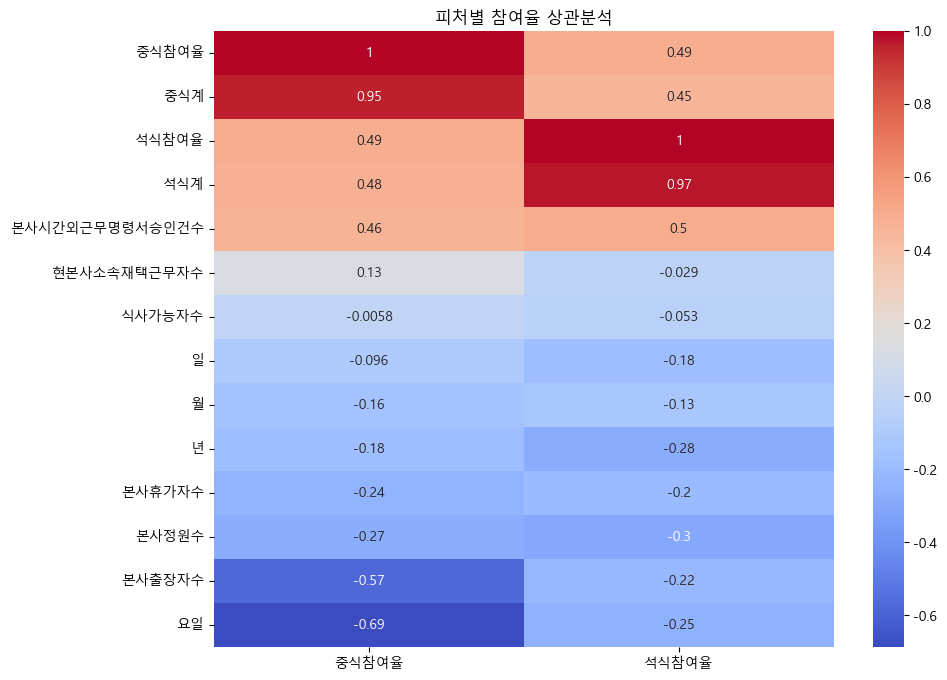

In [8]:
# 상관관계 분석 (참여율 기준)
plt.figure(figsize=(10, 8))
sns.heatmap(train.corr(numeric_only=True)[['중식참여율', '석식참여율']].sort_values(by='중식참여율', ascending=False), annot=True, cmap='coolwarm')
plt.title('피처별 참여율 상관분석')
plt.show()

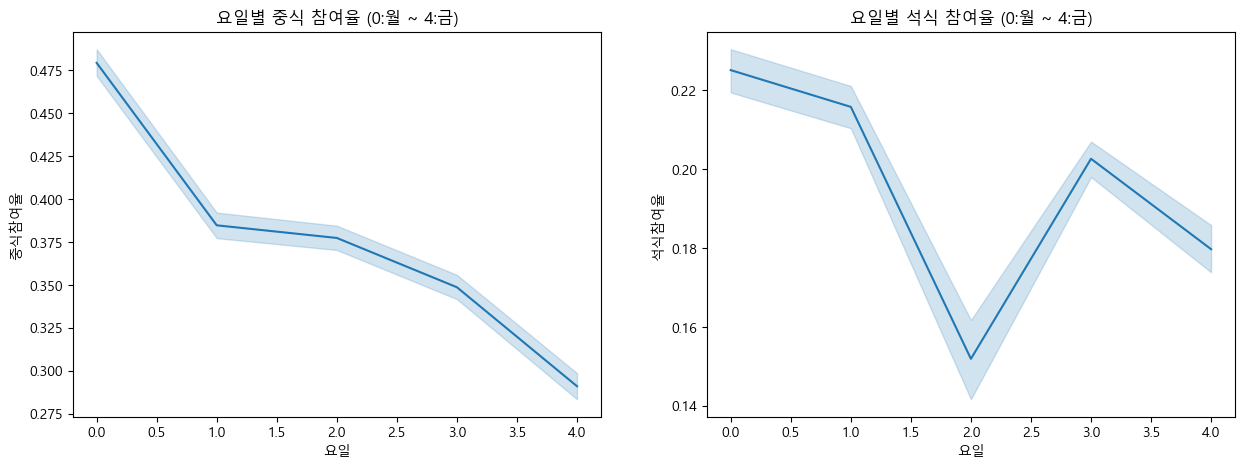

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=train, x='요일', y='중식참여율', ax=ax[0])
ax[0].set_title('요일별 중식 참여율 (0:월 ~ 4:금)')

sns.lineplot(data=train, x='요일', y='석식참여율', ax=ax[1])
ax[1].set_title('요일별 석식 참여율 (0:월 ~ 4:금)')
plt.show()

## 3. 모델링: XGBRegressor

In [10]:
features = ['월', '일', '요일', '식사가능자수', '본사출장자수', '본사시간외근무명령서승인건수']

x_train = train[features]
y_lunch = train['중식참여율']
y_dinner = train['석식참여율']
x_test = test[features]

print(f"사용 피처: {features}")

사용 피처: ['월', '일', '요일', '식사가능자수', '본사출장자수', '본사시간외근무명령서승인건수']


In [11]:
# 모델 생성 및 학습 (중식)
model_lunch = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5, random_state=42)
model_lunch.fit(x_train, y_lunch)

# 모델 생성 및 학습 (석식)
model_dinner = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5, random_state=42)
model_dinner.fit(x_train, y_dinner)

print("모델 학습 완료")

모델 학습 완료


## 4. 예측 및 결과 복원

In [12]:
# 참여율 예측
pred_lunch_ratio = model_lunch.predict(x_test)
pred_dinner_ratio = model_dinner.predict(x_test)

# 계수로 복원
final_pred_lunch = pred_lunch_ratio * test['식사가능자수']
final_pred_dinner = pred_dinner_ratio * test['식사가능자수']

submission['중식계'] = final_pred_lunch
submission['석식계'] = final_pred_dinner

submission.head()

,일자,중식계,석식계
0,2021-01-27,1007.040383,173.037545
1,2021-01-28,1010.500121,473.839536
2,2021-01-29,520.527756,267.648389
3,2021-02-01,1238.037794,513.842607
4,2021-02-02,1050.388657,574.429188


In [13]:
# 파일 저장
import os
if not os.path.exists('submission'):
    os.makedirs('submission')
    
submission.to_csv('submission/submission_v7.csv', index=False)
print("v7 제출 파일 생성 완료: submission/submission_v7.csv")

v7 제출 파일 생성 완료: submission/submission_v7.csv


## 5. 피처 중요도 시각화

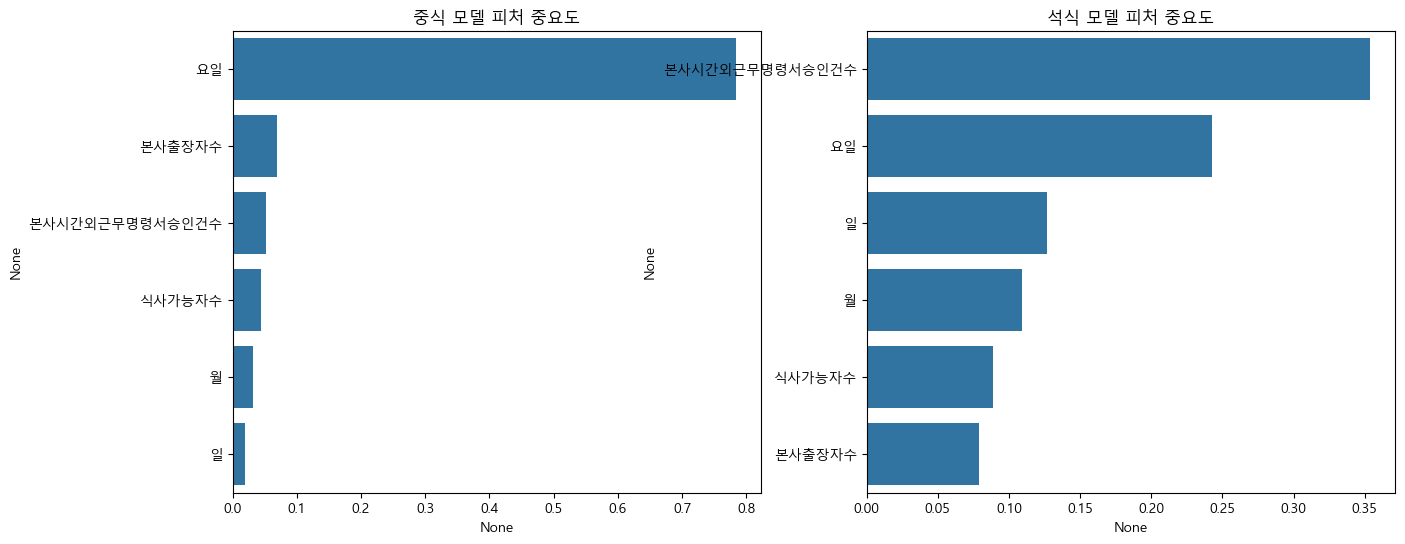

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

importances_lunch = pd.Series(model_lunch.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=importances_lunch, y=importances_lunch.index, ax=ax[0])
ax[0].set_title('중식 모델 피처 중요도')

importances_dinner = pd.Series(model_dinner.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=importances_dinner, y=importances_dinner.index, ax=ax[1])
ax[1].set_title('석식 모델 피처 중요도')

plt.show()